# 2 · Risk and Performance: Volatility, Sharpe Ratio, Drawdown

A return on its own says nothing about how much pain it took to earn it. This notebook covers the three numbers every quant reports next to a return: volatility, the Sharpe ratio and the maximum drawdown.

## 1. Motivation

Two funds both made 10% last year. One got there smoothly. The other lost 40% in March and recovered by December. Most investors would have sold the second fund at the bottom, so for them it was not the same 10%. To compare strategies fairly we need to measure **how bumpy** the ride was and **how deep** the worst hole was. Every project in the club, whichever team runs it, will be judged on these numbers.

## 2. Intuition

- **Volatility** measures how much returns jump around from day to day. It is the typical size of a move, up or down.
- **The Sharpe ratio** asks: *how much extra return did I get for each unit of volatility I accepted?* "Extra" means above what a risk-free T-bill would have paid. It is like miles per gallon for risk.
- **Drawdown** measures how far you are below your previous peak. Volatility treats up-moves and down-moves the same way. Drawdown only looks at the losses you actually lived through, which is what investors remember.

A good strategy has a high Sharpe ratio *and* a drawdown its investors can sit through.

## 3. The math

Let $R_t$ be the daily simple return (notebook 1) and $r_{f,t}$ the daily risk-free rate.

**Volatility.** The standard deviation of daily returns, scaled to a year:
$$
\sigma_{\text{annual}} = \sqrt{252}\;\operatorname{std}(R_t).
$$
The $\sqrt{252}$ comes from the fact that, if daily returns are independent, variances add over time: the variance of a 252-day sum is $252\,\sigma^2_{\text{daily}}$.

**Sharpe ratio.** Define the **excess return** $X_t = R_t - r_{f,t}$. Then
$$
\text{Sharpe} = \sqrt{252}\;\frac{\operatorname{mean}(X_t)}{\operatorname{std}(X_t)} .
$$
The mean scales with $252$ and the standard deviation with $\sqrt{252}$, so their ratio scales with $252/\sqrt{252} = \sqrt{252}$.

**Drawdown.** Let $V_t$ be the value of &#36;1 invested (the cumulative product from notebook 1), and $M_t = \max_{s \le t} V_s$ its running peak. Then
$$
DD_t = \frac{V_t}{M_t} - 1 \;\le\; 0, \qquad \text{Max drawdown} = \min_t DD_t .
$$

## 4. Code it

### 4.1 Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

prices = pd.read_csv("../data/prices.csv", index_col="date", parse_dates=True)

COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
plt.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 100, "axes.prop_cycle": plt.cycler(color=COLORS),
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.3, "lines.linewidth": 1.5, "font.size": 11,
})

assets = ["SPY", "AAPL", "TLT"]
returns = prices[assets].pct_change().dropna()

# ^IRX is the 13-week T-bill yield in annual percent, not a price.
# Convert it to a daily rate: divide by 100 (percent -> decimal) and by 252 (per year -> per day).
# We use yesterday's yield, since that is the rate you could have locked in at the start of today.
rf_daily = (prices["^IRX"].ffill() / 100 / 252).shift(1).reindex(returns.index)
print(f"Average risk-free rate over the sample: {rf_daily.mean() * 252:.2%} per year")

Average risk-free rate over the sample: 1.47% per year


### 4.2 One function for all three measures

Each line in `risk_report` corresponds to one formula from Section 3.

In [2]:
def max_drawdown(r):
    """Max drawdown of a return series: min over t of V_t / M_t - 1."""
    value = (1 + r).cumprod()        # V_t, value of $1
    peak = value.cummax()            # M_t, running peak
    return (value / peak - 1).min()  # deepest point below a peak

def risk_report(returns, rf_daily):
    excess = returns.sub(rf_daily, axis=0)                        # X_t = R_t - r_f,t
    years = len(returns) / 252
    return pd.DataFrame({
        "CAGR": (1 + returns).prod() ** (1 / years) - 1,          # notebook 1
        "Volatility": returns.std() * np.sqrt(252),               # sqrt(252) * std(R_t)
        "Sharpe": np.sqrt(252) * excess.mean() / excess.std(),    # sqrt(252) * mean(X) / std(X)
        "Max drawdown": returns.apply(max_drawdown),              # min_t DD_t
        "Worst day": returns.min(),
    })

report = risk_report(returns, rf_daily)
# Format for display: percentages everywhere except the Sharpe ratio
fmt = {"CAGR": "{:.1%}", "Volatility": "{:.1%}", "Sharpe": "{:.2f}", "Max drawdown": "{:.1%}", "Worst day": "{:.1%}"}
report.apply(lambda col: col.map(fmt[col.name].format))

,CAGR,Volatility,Sharpe,Max drawdown,Worst day
SPY,14.1%,17.0%,0.77,-33.7%,-10.9%
AAPL,26.7%,28.1%,0.93,-43.8%,-12.9%
TLT,2.1%,14.9%,0.11,-48.4%,-6.7%


Reading the table:

- **AAPL** grew fastest and had the best Sharpe ratio (about 0.9), but it also had the deepest stock drawdown (−44%) and the worst single day. Higher return came with a bumpier ride.
- **SPY** had a Sharpe ratio near 0.8 with a max drawdown of about −34%, which happened during the COVID crash in early 2020.
- **TLT** is the surprise. Long-term government bonds are often called "safe", yet TLT fell about 48% from its peak, deeper than either stock. Its Sharpe ratio is close to zero. Section 4.3 shows when that happened.

### 4.3 Drawdowns over time

The drawdown curve $DD_t$ shows *when* the losses happened and how long recovery took.

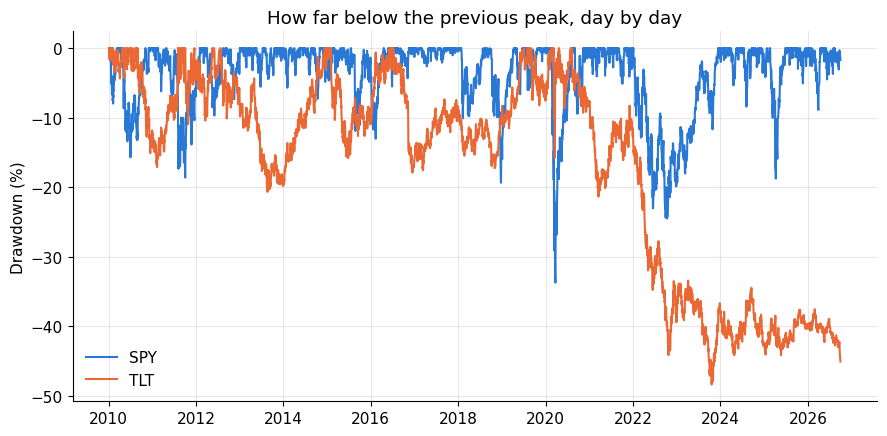

SPY's longest stretch below a previous peak: 488 trading days (~1.9 years)


In [3]:
value = (1 + returns).cumprod()
drawdown = value / value.cummax() - 1   # DD_t = V_t / M_t - 1

fig, ax = plt.subplots()
for t in ["SPY", "TLT"]:
    ax.plot(drawdown.index, drawdown[t] * 100, label=t)
ax.set_ylabel("Drawdown (%)")
ax.set_title("How far below the previous peak, day by day")
ax.legend(frameon=False, loc="lower left")
plt.tight_layout()
plt.show()

# How long was SPY "underwater" (below its peak) at most?
underwater = drawdown["SPY"] < 0
spell_id = (~underwater).cumsum()                      # a new id starts at every new peak
longest = underwater.groupby(spell_id).sum().max()     # longest run of underwater days
print(f"SPY's longest stretch below a previous peak: {longest} trading days (~{longest / 252:.1f} years)")

The two drawdown curves look completely different:

- **SPY** had a sharp, fast drawdown in 2020 that was recovered within months, and a slower one in 2022. Its longest stretch below a previous peak was about two years.
- **TLT** started falling in 2020 as interest rates began to rise. When rates rose fast in 2022, bond prices collapsed, and by the end of the sample it has *still* not recovered. "Safe" assets can have very long drawdowns. The risk-management notebooks come back to this.

### 4.4 Volatility is not constant

A single volatility number hides the fact that risk comes in waves. We estimate volatility over a rolling 3-month window (63 trading days) and compare it with the **VIX**. The VIX is the market's *forecast* of S&P 500 volatility over the next month, derived from option prices. Both are in annual percent, so they share one axis.

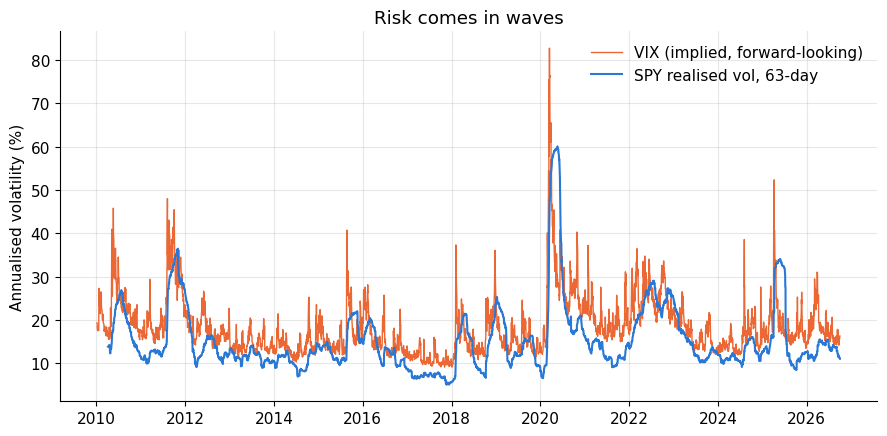

VIX was above realised vol on 84% of days


In [4]:
rolling_vol = returns["SPY"].rolling(63).std() * np.sqrt(252) * 100   # realised, annual %
vix = prices["^VIX"].reindex(returns.index)                            # implied, annual %

fig, ax = plt.subplots()
ax.plot(vix.index, vix, label="VIX (implied, forward-looking)", color=COLORS[1], linewidth=1)
ax.plot(rolling_vol.index, rolling_vol, label="SPY realised vol, 63-day", color=COLORS[0])
ax.set_ylabel("Annualised volatility (%)")
ax.set_title("Risk comes in waves")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

both = pd.concat([vix, rolling_vol], axis=1).dropna()
print(f"VIX was above realised vol on {(both.iloc[:, 0] > both.iloc[:, 1]).mean():.0%} of days")

Two patterns stand out:

1. **Volatility clusters.** Calm periods (2017, 2024) and turbulent periods (late 2011, 2020, 2022) each last for months. Today's volatility is a good forecast of next month's. This is why position sizing (PR5) scales positions by *recent* volatility.
2. **The VIX is usually above realised volatility.** Option buyers pay a premium for protection, so the market's forecast of volatility tends to be higher than what actually happens. This gap is called the **variance risk premium**, and it is a well-known source of returns for strategies that sell options.

## 5. Takeaways and where it breaks

- **Report all three together.** A high Sharpe ratio with a 60% drawdown is not a strategy most people can hold.
- **The $\sqrt{252}$ rule assumes independent days.** Returns that trend or mean-revert over days break it, and so does volatility clustering (Section 4.4). Treat annualised numbers as approximations.
- **Sharpe treats upside and downside the same.** A strategy that sells insurance can show a great Sharpe ratio for years, then lose everything in one crash. Always look at the worst day and the max drawdown, not just Sharpe.
- **Sample dependence.** These numbers are for 2010–2026, mostly a bull market. The same assets measured over 2000–2010 would look very different.
- **Sharpe ratios have big error bars.** With $N$ years of data, the standard error of an annual Sharpe ratio is roughly $1/\sqrt{N}$. With 16 years that is about ±0.25, so a Sharpe of 0.8 versus 0.9 is not a meaningful difference.

**What you could build:** a one-page "tear sheet" function that takes any return series and prints CAGR, volatility, Sharpe, max drawdown and the drawdown chart. Every team will need one to report results.